# Simple Multilayer Perceptron

## Imports

In [92]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt # To view image inline in the kernel
import pandas as pd
import numpy as np
from PIL import Image
import copy
import io

## Prepare Dataset

In [2]:
!rm -rf *.parquet
!wget -q 'https://huggingface.co/datasets/ylecun/mnist/resolve/main/mnist/test-00000-of-00001.parquet' -O 'test.parquet'
!wget -q 'https://huggingface.co/datasets/ylecun/mnist/resolve/main/mnist/train-00000-of-00001.parquet' -O 'train.parquet'

In [3]:
# Read the parquet file into an Arrow Table
def read_parquet_file_to_df(filename, num_data):
    return pq.read_table(filename).to_pandas().head(num_data)

train_set_size = 100
test_set_size = 20

train_df = read_parquet_file_to_df('train.parquet', train_set_size)
test_df = read_parquet_file_to_df('test.parquet', test_set_size)

## Visualization

In [17]:
train_df.head(1) # The data is already stored as a PNG image

,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

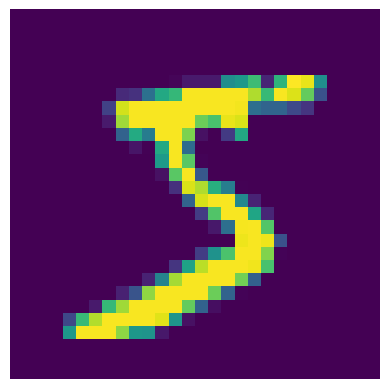

In [18]:
# To view the image (the first one)
img = Image.open(io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']))

plt.imshow(img)
plt.axis('off')

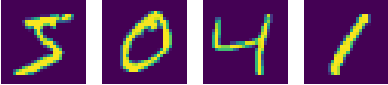

In [19]:
# Showing the first 4 images
num_images = 4
images = []
width, height = 100, 100
for byte_image_dict in train_df["image"].head(num_images):
    images.append(Image.open(io.BytesIO(byte_image_dict['bytes'])))

# The code below shows the images vertically
# for image in images:
#     plt.figure(figsize=(width, height), dpi=1) # To ensure that each plot gets it's own figure (not overwrite the previous figure)
#     plt.imshow(image)
#     plt.axis('off')
#     plt.show()

# The code below shows the images horizontally (using subplots)
fig, axes = plt.subplots(1, 4, figsize=(width, height), dpi=5)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis('off')
    ax.set_aspect('equal')


In [ ]:
# Create a numpy array from bytes
byte_image_data = io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']) # Encoded
image_data = Image.open(byte_image_data)

arr = np.array(image_data)

In [ ]:
# plt.imshow(arr, cmap='grey')
# # plt.colorbar()
# plt.show()

## CODE : Neural Network

Initialize the weights to **some values**. \
For this simple simulation, I am going to use 4 layers in total (input <-> HL<sub>1</sub> <-> HL<sub>2</sub> <-> output) with input dimension being 784 (28x28 image), 16 neurons for the HLs and 10 (0-9) outputs in total.

In [117]:
# Dataset Preparation
def get_np_img_array(df):
    arr = []
    for data in df["image"]:
        arr.append(np.array(Image.open(io.BytesIO(data['bytes']))))
    return arr

train_images = get_np_img_array(train_df)
test_images = get_np_img_array(test_df)

train_labels = train_df["label"].to_numpy()
test_labels = test_df["label"].to_numpy()

In [98]:
# There should a total of one weight matrix for each layer to layer
def populate_random(rows, cols):
    return np.random.rand(rows, cols) * 0.01

def init_weight_matrix(layers):
    wm = [None]
    for i in range(len(layers) - 1):
        wm.append(populate_random(layers[i], layers[i+1]))
    return wm

def init_bias_matrix(layers):
    bm = [None]
    for i in range(1, len(layers)):
        bm.append(
            np.zeros( (1, layers[i]) )
        )
    return bm

layers = [784, 16, 16, 10]
weight_matrix = init_weight_matrix(layers)
bias_matrix = init_bias_matrix(layers)
zvalues = [None] * len(layers)

The first entry is "None" to keep the relevance with the formula:
$$a_k^{(L)} = \sigma \left( \sum_k w_{kj}^{(L)} a_j^{(L-1)} + b_k^{(L)} \right)$$


#### Training
**Forward & Backward Propagation**

In [125]:
def print_shape(lists):
    for l in lists:
        print(len(l), len(l[0]))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

def one_hot_encode(num_classes, label):
    return np.eye(num_classes)[label].reshape(1, -1)

def mid_term(neurons, weights, biases):
    return (neurons @ weights) + biases

def del_L(neurons, outputs):
    cost_derivate = 2 * (neurons - outputs)
    return sigmoid_derivative(zvalues[-1]) * cost_derivate

def del_l(del_l_plus_1, layer):
    return (del_l_plus_1 @ weight_matrix[layer+1].T) * sigmoid_derivative(zvalues[layer])

def forward(neurons, image):
    neurons[0] = np.array(image).flatten().reshape(1, -1)
    for layer in range(1, len(bias_matrix)):
        z = mid_term(neurons[layer-1], weight_matrix[layer], bias_matrix[layer])
        zvalues[layer] = z
        neurons[layer] = sigmoid(z)

def backward(neurons, image, outputs):
    error_terms = [None] * len(neurons)

    # output layer
    error_terms[-1] = del_L(neurons[-1], outputs)

    del_w = neurons[-2].T @ error_terms[-1]
    del_b = error_terms[-1]

    lr = 0.01
    weight_matrix[-1] -= lr * del_w
    bias_matrix[-1] -= lr * del_b

    # hidden layers
    for layer in range(len(neurons) - 2, 0, -1):
        error_terms[layer] = del_l(error_terms[layer + 1], layer)

        del_w = neurons[layer-1].T @ error_terms[layer]
        del_b = error_terms[layer]

        weight_matrix[layer] -= lr * del_w
        bias_matrix[layer] -= lr * del_b


In [126]:
neurons = [None]
for i in range(1, len(layers)):
    neurons.append(np.random.rand(1, layers[i]))

output_layer = len(neurons) - 1

def propagate():
    for i, image in enumerate(train_images):
        forward(neurons, image)
        backward( neurons, image, one_hot_encode(10, train_labels[i]) )

propagate()

## Testing

In [127]:
def predict(image):
    forward(neurons, image)
    return np.argmax(neurons[-1])

def accuracy(images, labels):
    correct = 0

    for i, image in enumerate(images):
        pred = predict(image)
        if pred == labels[i]:
            correct += 1

    return correct / len(images)

In [132]:
correct = sum(predict(img) == label for img, label in zip(test_images, test_labels))
acc = correct / len(test_labels)
print("Accuracy:", acc)

Accuracy: 0.0


In [129]:
print(test_labels)

[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]
